In [20]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [21]:
colors = sns.color_palette()
colors

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

# Results for PPO, PD Control and Baseline

In [22]:
ra = [10000, 100000, 1000000, 5000000]
dfs = []

# read from csv

for r in ra:
    path = f"res/baseline_full_ra{r}.csv"
    try:
        dfs.append(pandas.read_csv(path))
    except Exception as e:
        pass

print(dfs[3].columns)

Index(['ep0/time', 'fiery-meadow-18 - _step', 'fiery-meadow-18 - _step__MIN',
       'fiery-meadow-18 - _step__MAX', 'fiery-meadow-18 - ep0/nusselt_obs',
       'fiery-meadow-18 - ep0/nusselt_obs__MIN',
       'fiery-meadow-18 - ep0/nusselt_obs__MAX'],
      dtype='object')


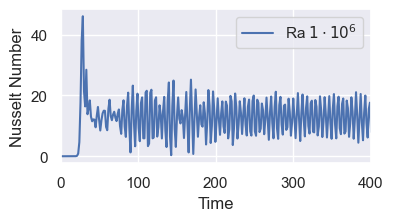

In [23]:

# plot
plt.figure(figsize=(4, 2))
sns.set_theme()

# x axis
plt.xlabel("Time")
plt.xlim(0, 400)
plt.xticks(np.arange(0, 401, 100), np.arange(0, 401, 100))

# y axis
plt.ylabel("Nusselt Number")

# plot data
#sns.lineplot(data=dfs[0], x="ep0/time", y="earnest-firebrand-15 - ep0/nusselt_obs", label=r"Ra $1 \cdot 10^4 $")
#sns.lineplot(data=dfs[1], x="ep0/time", y="clean-water-16 - ep0/nusselt_obs", label=r"Ra $1 \cdot 10^5 $")
sns.lineplot(data=dfs[2], x="ep0/time", y="smooth-star-17 - ep0/nusselt_obs", label=r"Ra $1 \cdot 10^6 $")
#sns.lineplot(data=dfs[3], x="ep0/time", y="fiery-meadow-18 - ep0/nusselt_obs", label=r"Ra $5 \cdot 10^6 $")

plt.legend()
#plt.show()
plt.savefig(f"/Users/tmarkmann/Downloads/baseline_10e6.svg", bbox_inches="tight")

In [24]:
path = f"res/nusselt_example.csv"
try:
    df_nu = pandas.read_csv(path)
    print(df_nu.columns)
except Exception as e:
    print(e)

Index(['ep0/time', 'sleek-dew-647-134988 - _step',
       'sleek-dew-647-134988 - _step__MIN',
       'sleek-dew-647-134988 - _step__MAX',
       'sleek-dew-647-134988 - ep0/nusselt_obs',
       'sleek-dew-647-134988 - ep0/nusselt_obs__MIN',
       'sleek-dew-647-134988 - ep0/nusselt_obs__MAX'],
      dtype='object')


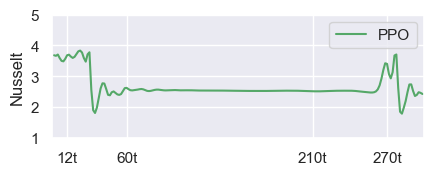

In [25]:
# plot
plt.figure(figsize=(4.8, 1.6))
sns.set_theme()

# x axis
#plt.xlabel("Time")
plt.xlim(0, 300)
plt.xticks([12, 60, 210, 270], labels=["12t", "60t", "210t", "270t"])

# y axis
plt.ylabel("Nusselt")
plt.ylim(1, 5)

# plot data
ax = sns.lineplot(data=df_nu, x="ep0/time", y="sleek-dew-647-134988 - ep0/nusselt_obs", label="PPO", color=colors[2])
ax.set(xlabel=None)
plt.legend(loc="upper right")
#plt.tight_layout()
plt.savefig("/Users/tmarkmann/Downloads/nusselt_example.svg", bbox_inches="tight")